In [ ]:
import yfinance as yf

In [ ]:
d=yf.download("AMZN",start="2025-09-29",end="2026-03-29")
d

/tmp/ipykernel_10901/297045901.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d=yf.download("AMZN",start="2025-09-29",end="2026-03-29")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2025-09-29,222.169998,222.600006,219.300003,220.080002,44259200
2025-09-30,219.570007,222.240005,217.889999,222.029999,48396400
2025-10-01,220.630005,222.149994,216.610001,217.360001,43933800
2025-10-02,222.410004,222.809998,218.949997,221.009995,41258600
2025-10-03,219.509995,224.199997,219.339996,223.440002,43639000
...,...,...,...,...,...
2026-03-23,210.139999,212.800003,209.509995,209.789993,44277400
2026-03-24,207.240005,209.350006,206.639999,207.949997,35351400


In [ ]:
d.head()

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2025-09-29,222.169998,222.600006,219.300003,220.080002,44259200
2025-09-30,219.570007,222.240005,217.889999,222.029999,48396400
2025-10-01,220.630005,222.149994,216.610001,217.360001,43933800
2025-10-02,222.410004,222.809998,218.949997,221.009995,41258600
2025-10-03,219.509995,224.199997,219.339996,223.440002,43639000


In [ ]:
st=yf.Ticker("AMZN")
print(st.info['currentPrice'])

199.34


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
ts=d['Close']

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
r=adfuller(ts)
print(r)

(np.float64(-1.682801997242479), np.float64(0.4399944760075132), 1, 123, {'1%': np.float64(-3.4846672514209773), '5%': np.float64(-2.8853397507076006), '10%': np.float64(-2.5794629869786503)}, np.float64(654.1401614401597))


In [ ]:
tsd=ts.diff().dropna().head()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(ts,order=(2,1,2))
model_fit=model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

                               SARIMAX Results                                
Dep. Variable:                   AMZN   No. Observations:                  125
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -362.267
Date:                Sun, 29 Mar 2026   AIC                            734.535
Time:                        10:48:01   BIC                            748.636
Sample:                             0   HQIC                           740.263
                                - 125                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0027      2.812     -0.001      0.999      -5.515       5.509
ar.L2          0.2764      1.130      0.244      0.807      -1.939       2.492
ma.L1          0.1116      2.805      0.040      0.9

In [ ]:
f=model_fit.forecast(steps=5)
print(f)

125    198.821159
126    198.711833
127    198.568744
128    198.538919
129    198.499456
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


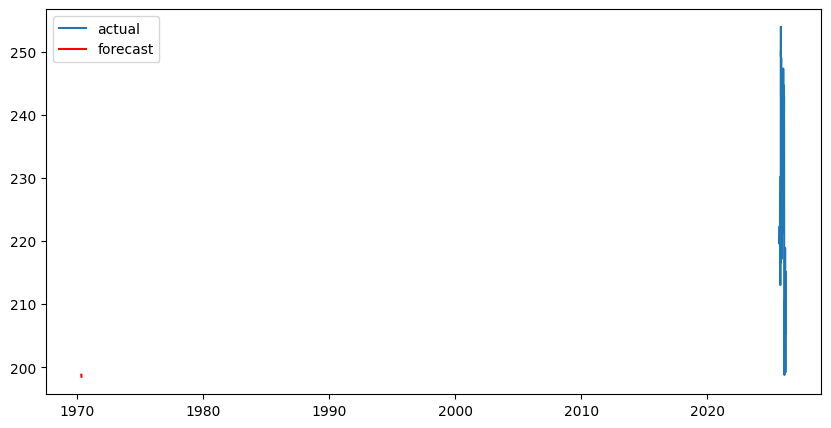

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(ts,label="actual")
plt.plot(f,label="forecast",color="red")
plt.legend()
plt.show()